Simulaciones

In [17]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## Aceptación y Rechazo

Sea f una densidad objetivo de la cual queremos simular. Supongamos que
existe una densidad g (facil de simular) y una constante M > 0 tal que:
 - f (x) ≤ M · g(x) ∀x ∈ Soporte(f )
Entonces el siguiente algoritmo genera observaciones con densidad f :
 - 1 Generar Y ∼ g
 - 2 Generar U ∼ Uniforme(0, 1), independiente de Y
 - 3 Si U ≤
        f (Y )
        M·g(Y )
    , aceptar Y como muestra de f
 - 4 Si no, rechazar y regresar al paso 1

In [18]:

# ─────────────────────────────────────────────
# MÉTODO DE ACEPTACIÓN-RECHAZO
# ─────────────────────────────────────────────
# Objetivo: simular de f(x) ∝ x^2 * exp(-x/2)  en [0, ∞)
# (Gamma(3, 2) con parámetros forma=3, escala=2)
#
# Densidad propuesta g: Exponencial(lambda=0.5)
# Condición del teorema: f(x) ≤ M · g(x)  ∀x ∈ Soporte(f)
# ─────────────────────────────────────────────

# --- Densidades ---
def f(x):
    """Densidad objetivo (no normalizada): proporcional a Gamma(3,2)."""
    return stats.gamma.pdf(x, a=3, scale=2)

def g(x):
    """Densidad propuesta: Exponencial(lambda=0.5)."""
    return stats.expon.pdf(x, scale=2)   # scale = 1/lambda

# --- Constante M ---
# M = sup_x [ f(x) / g(x) ]
# Para Gamma(3,2) sobre Exponencial(lambda=0.5) se puede demostrar que M ≈ 2
# (encontrado numéricamente para ser rigurosos)
x_grid = np.linspace(1e-6, 30, 10_000)
M = np.max(f(x_grid) / g(x_grid)) * 1.01   # margen de seguridad del 1%
print(f"Constante M utilizada: {M:.4f}")


Constante M utilizada: 113.6250


#### Algoritmo de Aceptacion y rechazo

In [19]:

# --- Algoritmo de Aceptación-Rechazo ---
"""
    Genera n_samples muestras de f usando el método de aceptación-rechazo.

    Parámetros
    ----------
    n_samples  : int   – número de muestras deseadas
    M          : float – constante de cobertura (f ≤ M·g en todo el soporte)
    f          : callable – densidad objetivo
    g_sampler  : callable – genera una muestra de g y evalúa g en ella
                            retorna (Y, g(Y))
"""
def acceptance_rejection(n_samples, M, f, g_sampler):
    muestras = []
    intentos = 0

    while len(muestras) < n_samples:
        # Paso 1 – Generar Y ~ g
        Y, gY = g_sampler()

        # Paso 2 – Generar U ~ Uniforme(0,1), independiente de Y
        U = np.random.uniform(0, 1)

        intentos += 1

        # Paso 3 – Criterio de aceptación
        if U <= f(Y) / (M * gY):
            muestras.append(Y)          # aceptar Y como muestra de f
        # Paso 4 – Si no, rechazar y volver al paso 1

    tasa_acept = n_samples / intentos
    return np.array(muestras), tasa_acept


# Sampler de g: retorna (Y, g(Y)) con Y ~ Exponencial(lambda=0.5)
def g_sampler():
    Y = np.random.exponential(scale=2)
    return Y, g(Y)


#### Simulacion 

In [20]:

# --- Simulación ---
np.random.seed(42)
N = 10_000
muestras, tasa = acceptance_rejection(N, M, f, g_sampler)

print(f"Muestras generadas : {N}")
print(f"Tasa de aceptación : {tasa:.4f}  (teórica aprox 1/M = {1/M:.4f})")
print(f"Media muestral     : {muestras.mean():.4f}  (teórica = 6.0)")
print(f"Varianza muestral  : {muestras.var():.4f}   (teórica = 12.0)")



Muestras generadas : 10000
Tasa de aceptación : 0.0087  (teórica aprox 1/M = 0.0088)
Media muestral     : 5.9617  (teórica = 6.0)
Varianza muestral  : 11.9889   (teórica = 12.0)


#### Panel de visualizacion

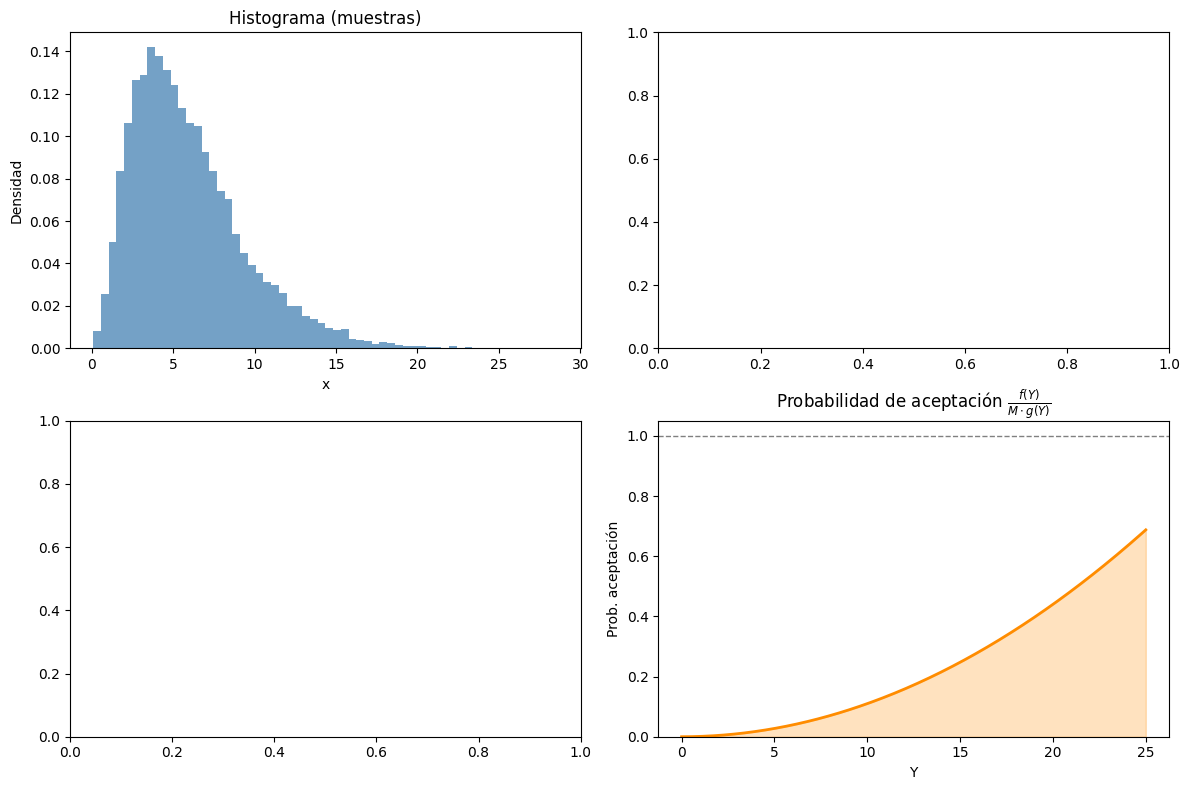

In [21]:
# --- Visualización (4 paneles) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax = axes.ravel()

# 1) Histograma solo
ax[0].hist(muestras, bins=60, density=True, color="steelblue", alpha=0.75)
ax[0].set_title("Histograma (muestras)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("Densidad")

# 4) Probabilidad de aceptación
ax[3].plot(x_plot, prob_acept, color="darkorange", lw=2)
ax[3].axhline(1, color="gray", lw=1, ls="--")
ax[3].fill_between(x_plot, prob_acept, alpha=0.25, color="darkorange")
ax[3].set_title(r"Probabilidad de aceptación $\frac{f(Y)}{M \cdot g(Y)}$")
ax[3].set_xlabel("Y")
ax[3].set_ylabel("Prob. aceptación")
ax[3].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Simulación Beta(2,2) por Aceptación-Rechazo

Densidad objetivo:
$$f(x) = 6x(1-x), \quad x \in [0,1]$$

Densidad propuesta:
$$g(x) = 1, \quad x \in [0,1] \quad (\text{Uniforme}(0,1))$$

Constante de cobertura:
$$M = \frac{3}{2}$$

Se cumple que $f(x) \le M \cdot g(x)$ para todo $x \in [0,1]$, ya que el máximo de $f$ se alcanza en $x=1/2$ con valor $3/2$.

Criterio de aceptación:
$$U \le \frac{f(Y)}{M \cdot g(Y)} = \frac{6Y(1-Y)}{3/2} = 4Y(1-Y)$$

In [22]:
# ─────────────────────────────────────────────
# Simulación de Beta(2,2):  f(x) = 6x(1-x)
# Propuesta g(x) = Uniforme(0,1),  M = 3/2
# ─────────────────────────────────────────────

# --- Densidades ---
def f_beta(x):
    """Densidad objetivo Beta(2,2): f(x) = 6x(1-x) en [0,1]."""
    return 6 * x * (1 - x)

def g_unif(x):
    """Densidad propuesta Uniforme(0,1)."""
    return np.where((x >= 0) & (x <= 1), 1.0, 0.0)

M_beta = 3 / 2
print(f"Constante M utilizada: {M_beta}")

# --- Sampler de g: retorna (Y, g(Y)) con Y ~ Uniforme(0,1) ---
def g_unif_sampler():
    Y = np.random.uniform(0, 1)
    return Y, 1.0   # g(Y) = 1 para todo Y en [0,1]

# --- Simulación reutilizando el algoritmo general ---
np.random.seed(42)
N = 10_000
muestras_beta, tasa_beta = acceptance_rejection(N, M_beta, f_beta, g_unif_sampler)

print(f"Muestras generadas : {N}")
print(f"Tasa de aceptación : {tasa_beta:.4f}  (teórica = 1/M = {1/M_beta:.4f})")
print(f"Media muestral     : {muestras_beta.mean():.4f}  (teórica = 0.5)")
print(f"Varianza muestral  : {muestras_beta.var():.4f}  (teórica = 0.05)")

Constante M utilizada: 1.5
Muestras generadas : 10000
Tasa de aceptación : 0.6748  (teórica = 1/M = 0.6667)
Media muestral     : 0.5002  (teórica = 0.5)
Varianza muestral  : 0.0492  (teórica = 0.05)


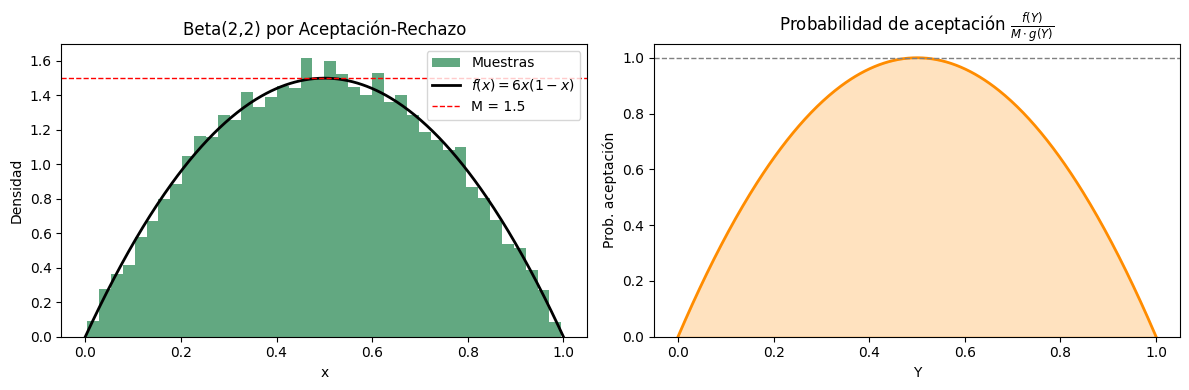

In [23]:
# --- Visualización: histograma vs densidad teórica ---
x_plot = np.linspace(0, 1, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma + densidad teórica
axes[0].hist(muestras_beta, bins=40, density=True,
             color="seagreen", alpha=0.75, label="Muestras")
axes[0].plot(x_plot, f_beta(x_plot), color="black", lw=2, label=r"$f(x)=6x(1-x)$")
axes[0].axhline(M_beta, color="red", ls="--", lw=1, label=f"M = {M_beta}")
axes[0].set_title("Beta(2,2) por Aceptación-Rechazo")
axes[0].set_xlabel("x"); axes[0].set_ylabel("Densidad")
axes[0].legend()

# Probabilidad de aceptación f(Y)/(M·g(Y))
prob_acept_beta = f_beta(x_plot) / (M_beta * 1.0)
axes[1].plot(x_plot, prob_acept_beta, color="darkorange", lw=2)
axes[1].fill_between(x_plot, prob_acept_beta, alpha=0.25, color="darkorange")
axes[1].axhline(1, color="gray", lw=1, ls="--")
axes[1].set_title(r"Probabilidad de aceptación $\frac{f(Y)}{M\cdot g(Y)}$")
axes[1].set_xlabel("Y"); axes[1].set_ylabel("Prob. aceptación")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()